In [28]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA, PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_SPLITS = 5
MAX_BLOCK_PCA_COMPONENTS = 50
MAX_CCA_INPUT_PCS = 10
MAX_CCA_COMPONENTS = 5
MAX_PLS_COMPONENTS = 30

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
BLOCK_FIGURES_DIR = FIGURES_DIR / "o2pls_inspired_blocks"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BLOCK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_DIRS = [DATA_RAW]

def find_file(candidate_names, search_dirs=SEARCH_DIRS):
    for directory in search_dirs:
        for name in candidate_names:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidate_names}")

def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:80] if text else "unknown"


# 1. Load Raw Data and Descriptor Metadata

In [29]:
FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx"]),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx"]),
    "admet": find_file(["ADMET.xlsx"]),
}

desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
admet_train = pd.read_excel(FILES["admet"], sheet_name="training")

smiles_col = "SMILES"
X_all = desc_train.drop(columns=[smiles_col]).apply(pd.to_numeric, errors="coerce")
y = activity_train["pIC50"].astype(float)

preprocessing_path = RESULTS_DIR / "descriptor_preprocessing_candidates.csv"
if not preprocessing_path.exists():
    raise FileNotFoundError(
        "descriptor_preprocessing_candidates.csv was not found. "
        "Please run 01_data_audit_and_problem_formulation.ipynb first."
    )

preprocessing_candidates = pd.read_csv(preprocessing_path)

required_cols = {"descriptor", "candidate_super_block", "is_constant"}
missing_cols = required_cols - set(preprocessing_candidates.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in preprocessing_candidates: {missing_cols}")

for col in ["is_constant", "is_near_constant", "is_binary_like", "is_rare_binary_like"]:
    if col in preprocessing_candidates.columns:
        preprocessing_candidates[col] = preprocessing_candidates[col].fillna(False).astype(bool)
    else:
        preprocessing_candidates[col] = False

preprocessing_candidates["candidate_super_block"] = (
    preprocessing_candidates["candidate_super_block"].fillna("not_assigned")
)

print("Descriptor training shape:", desc_train.shape)
print("Activity training shape:", activity_train.shape)
print("ADMET training shape:", admet_train.shape)
print("Preprocessing candidates shape:", preprocessing_candidates.shape)

display(
    preprocessing_candidates["candidate_super_block"]
    .value_counts(dropna=False)
    .reset_index(name="n_descriptors")
)


Descriptor training shape: (1974, 730)
Activity training shape: (1974, 3)
ADMET training shape: (1974, 6)
Preprocessing candidates shape: (729, 24)


,candidate_super_block,n_descriptors
0,block_X_local_electronic_atom_environment,553
1,block_Y_topological_connectivity_structure,136
2,not_assigned,40


# 2. Define the Two Candidate Descriptor Blocks

In [30]:
BLOCK_X_LABEL = "block_X_local_electronic_atom_environment"
BLOCK_Y_LABEL = "block_Y_topological_connectivity_structure"

available_descriptors = set(X_all.columns)

metadata_cols = [
    "descriptor",
    "descriptor_category",
    "descriptor_numeric_type",
    "candidate_super_block",
    "is_constant",
    "is_near_constant",
    "is_rare_binary_like",
    "dominant_value_ratio",
]
metadata_cols = [c for c in metadata_cols if c in preprocessing_candidates.columns]

primary_metadata = preprocessing_candidates[
    preprocessing_candidates["descriptor"].isin(available_descriptors)
    & (~preprocessing_candidates["is_constant"])
].copy()

block_x_descriptors = primary_metadata.loc[
    primary_metadata["candidate_super_block"] == BLOCK_X_LABEL,
    "descriptor",
].tolist()

block_y_descriptors = primary_metadata.loc[
    primary_metadata["candidate_super_block"] == BLOCK_Y_LABEL,
    "descriptor",
].tolist()

not_assigned_descriptors = primary_metadata.loc[
    primary_metadata["candidate_super_block"] == "not_assigned",
    "descriptor",
].tolist()

if len(block_x_descriptors) == 0 or len(block_y_descriptors) == 0:
    raise ValueError(
        "One of the candidate blocks is empty. Check candidate_super_block labels "
        "in descriptor_preprocessing_candidates.csv."
    )

block_descriptor_summary = pd.DataFrame([
    {
        "block_name": BLOCK_X_LABEL,
        "role": "candidate_block",
        "n_descriptors": len(block_x_descriptors),
    },
    {
        "block_name": BLOCK_Y_LABEL,
        "role": "candidate_block",
        "n_descriptors": len(block_y_descriptors),
    },
    {
        "block_name": "not_assigned",
        "role": "reference_only_not_candidate_block",
        "n_descriptors": len(not_assigned_descriptors),
    },
])

block_descriptor_summary.to_csv(
    RESULTS_DIR / "o2pls_block_descriptor_summary.csv",
    index=False,
)

display(block_descriptor_summary)

block_members = primary_metadata[
    primary_metadata["candidate_super_block"].isin([BLOCK_X_LABEL, BLOCK_Y_LABEL])
][metadata_cols].copy()
block_members.to_csv(RESULTS_DIR / "o2pls_candidate_block_members.csv", index=False)

display(block_members.head(20))


,block_name,role,n_descriptors
0,block_X_local_electronic_atom_environment,candidate_block,335
1,block_Y_topological_connectivity_structure,candidate_block,129
2,not_assigned,reference_only_not_candidate_block,40


,descriptor,descriptor_category,descriptor_numeric_type,candidate_super_block,is_constant,is_near_constant,is_rare_binary_like,dominant_value_ratio
225,nHsSH,Atom type electrotopological state,binary_like,block_X_local_electronic_atom_environment,False,True,True,0.999493
226,nssssNp,Atom type electrotopological state,binary_like,block_X_local_electronic_atom_environment,False,True,True,0.999493
227,nsSH,Atom type electrotopological state,binary_like,block_X_local_electronic_atom_environment,False,True,True,0.999493
228,ndssS,Atom type electrotopological state,binary_like,block_X_local_electronic_atom_environment,False,True,True,0.999493
229,SHsSH,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493
230,SssssNp,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493
231,SsSH,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493
232,SdssS,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493
233,minHsSH,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493
234,minssssNp,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,True,False,0.999493


# 3. Block-Level Preprocessing

In [31]:
def prepare_block_matrix(X_all, descriptors):
    X_df = X_all[descriptors].copy()
    if X_df.isna().sum().sum() > 0:
        X_df = X_df.fillna(X_df.median())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    return X_df, X_scaled, scaler

X_block_df, X_block_scaled, X_block_scaler = prepare_block_matrix(X_all, block_x_descriptors)
Y_block_df, Y_block_scaled, Y_block_scaler = prepare_block_matrix(X_all, block_y_descriptors)

print("Block X matrix:", X_block_df.shape)
print("Block Y matrix:", Y_block_df.shape)


Block X matrix: (1974, 335)
Block Y matrix: (1974, 129)


# 4. PCA Within Each Candidate Block

Block-wise PCA is used to inspect the dominant latent structure within each descriptor block before examining cross-block association.


In [32]:
def fit_block_pca(X_scaled, descriptors, block_label, max_components=MAX_BLOCK_PCA_COMPONENTS):
    n_components = int(min(max_components, X_scaled.shape[0] - 1, X_scaled.shape[1]))
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    scores = pca.fit_transform(X_scaled)

    score_cols = [f"{safe_filename(block_label)}_PC{i+1}" for i in range(n_components)]
    scores_df = pd.DataFrame(scores, columns=score_cols)
    scores_df.insert(0, "SMILES", desc_train[smiles_col].astype(str).values)
    scores_df["pIC50"] = y.values

    for col in admet_train.columns:
        if col != smiles_col:
            scores_df[col] = admet_train[col].values

    explained_df = pd.DataFrame({
        "block_label": block_label,
        "component": np.arange(1, n_components + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
    })

    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}_loading" for i in range(n_components)],
    )
    loadings_df.insert(0, "descriptor", descriptors)
    loadings_df.insert(1, "block_label", block_label)

    return {
        "pca": pca,
        "scores": scores,
        "scores_df": scores_df,
        "explained_df": explained_df,
        "loadings_df": loadings_df,
    }

block_x_pca = fit_block_pca(X_block_scaled, block_x_descriptors, BLOCK_X_LABEL)
block_y_pca = fit_block_pca(Y_block_scaled, block_y_descriptors, BLOCK_Y_LABEL)

block_pca_explained = pd.concat(
    [block_x_pca["explained_df"], block_y_pca["explained_df"]],
    ignore_index=True,
)
block_pca_explained.to_csv(RESULTS_DIR / "o2pls_block_pca_explained_variance.csv", index=False)

block_x_pca["scores_df"].to_csv(RESULTS_DIR / "o2pls_block_X_pca_scores.csv", index=False)
block_y_pca["scores_df"].to_csv(RESULTS_DIR / "o2pls_block_Y_pca_scores.csv", index=False)

pd.concat([block_x_pca["loadings_df"], block_y_pca["loadings_df"]], ignore_index=True).to_csv(
    RESULTS_DIR / "o2pls_block_pca_loadings.csv",
    index=False,
)

display(block_pca_explained.groupby("block_label").head(10))


,block_label,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,block_X_local_electronic_atom_environment,1,0.139601,0.139601
1,block_X_local_electronic_atom_environment,2,0.099186,0.238786
2,block_X_local_electronic_atom_environment,3,0.073328,0.312114
3,block_X_local_electronic_atom_environment,4,0.055278,0.367392
4,block_X_local_electronic_atom_environment,5,0.046892,0.414284
5,block_X_local_electronic_atom_environment,6,0.035336,0.449620
6,block_X_local_electronic_atom_environment,7,0.030806,0.480425
7,block_X_local_electronic_atom_environment,8,0.029442,0.509868
8,block_X_local_electronic_atom_environment,9,0.025346,0.535214
9,block_X_local_electronic_atom_environment,10,0.024811,0.560025


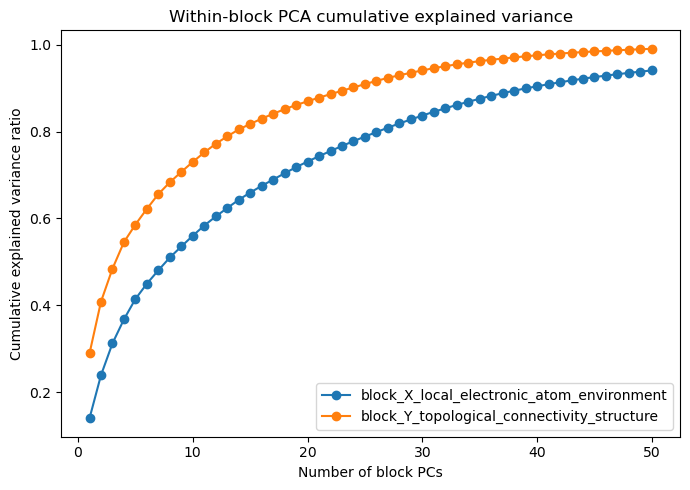

In [33]:
plt.figure(figsize=(7, 5))
for block_label, df in block_pca_explained.groupby("block_label"):
    plt.plot(
        df["component"],
        df["cumulative_explained_variance_ratio"],
        marker="o",
        label=block_label,
    )
plt.xlabel("Number of block PCs")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Within-block PCA cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig(BLOCK_FIGURES_DIR / "block_pca_cumulative_explained_variance.png", dpi=200)
plt.show()

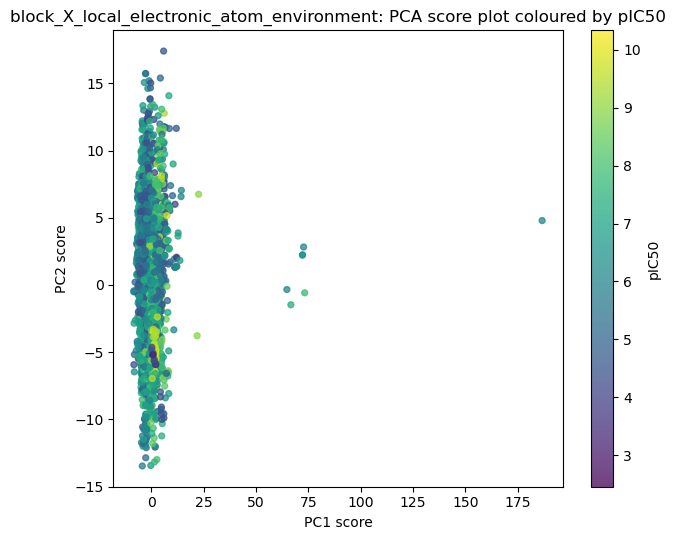

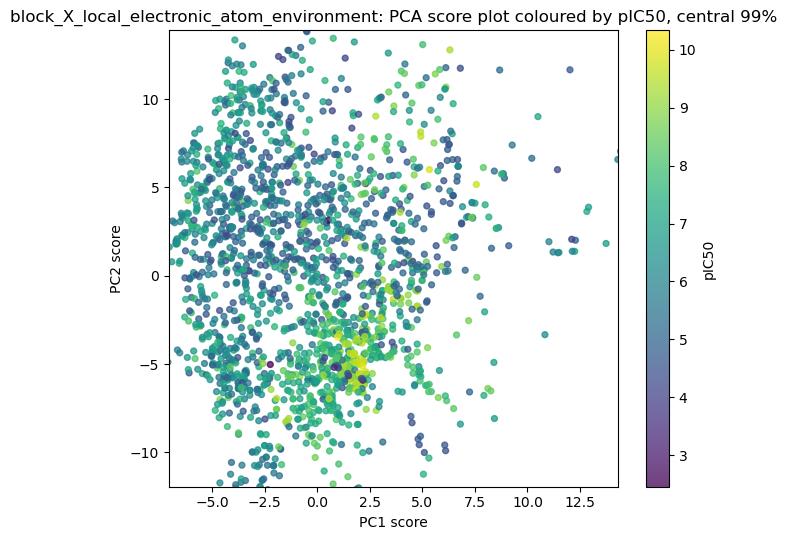

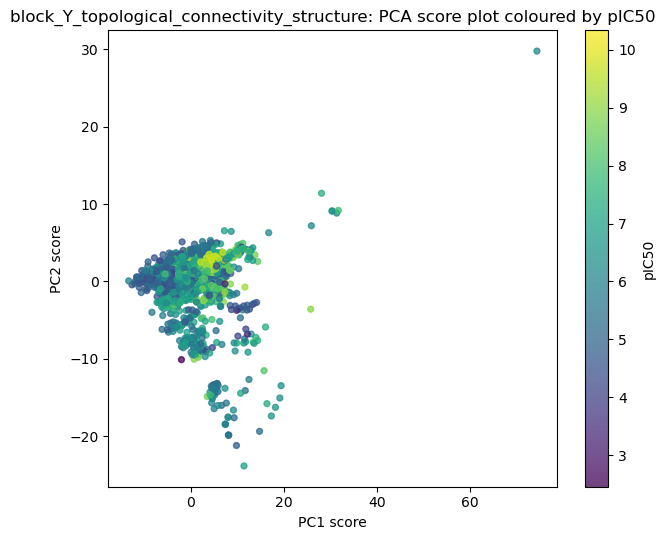

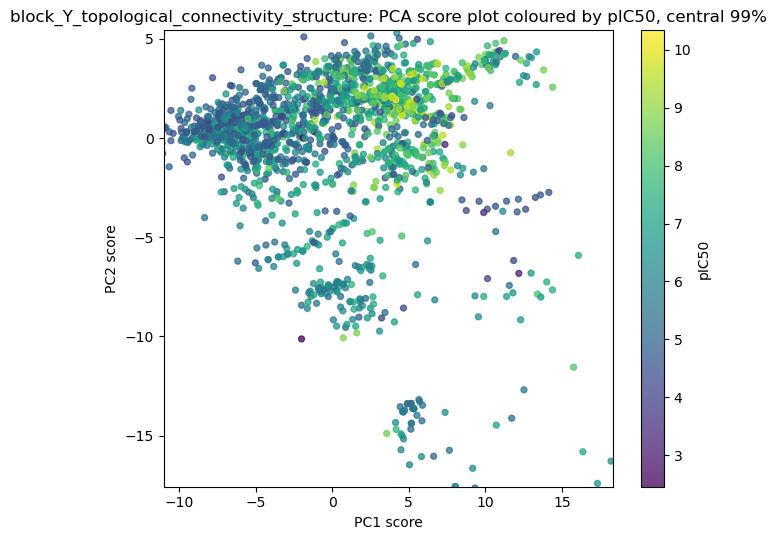

In [34]:
def plot_block_scores(scores_df, pc1_col, pc2_col, block_label):
    # Full plot
    plt.figure(figsize=(6.5, 5.5))
    scatter = plt.scatter(
        scores_df[pc1_col],
        scores_df[pc2_col],
        c=scores_df["pIC50"],
        s=18,
        alpha=0.75,
    )
    plt.colorbar(scatter, label="pIC50")
    plt.xlabel("PC1 score")
    plt.ylabel("PC2 score")
    plt.title(f"{block_label}: PCA score plot coloured by pIC50")
    plt.tight_layout()
    plt.savefig(
        BLOCK_FIGURES_DIR / f"{safe_filename(block_label)}_pca_score_plot_coloured_by_pIC50.png",
        dpi=200,
    )
    plt.show()

    # Zoomed plot for the central sample cloud
    x_low, x_high = scores_df[pc1_col].quantile([0.005, 0.995])
    y_low, y_high = scores_df[pc2_col].quantile([0.005, 0.995])

    plt.figure(figsize=(6.5, 5.5))
    scatter = plt.scatter(
        scores_df[pc1_col],
        scores_df[pc2_col],
        c=scores_df["pIC50"],
        s=18,
        alpha=0.75,
    )
    plt.colorbar(scatter, label="pIC50")
    plt.xlim(x_low, x_high)
    plt.ylim(y_low, y_high)
    plt.xlabel("PC1 score")
    plt.ylabel("PC2 score")
    plt.title(f"{block_label}: PCA score plot coloured by pIC50, central 99%")
    plt.tight_layout()
    plt.savefig(
        BLOCK_FIGURES_DIR / f"{safe_filename(block_label)}_pca_score_plot_coloured_by_pIC50_zoomed.png",
        dpi=200,
    )
    plt.show()


x_pc_prefix = safe_filename(BLOCK_X_LABEL)
y_pc_prefix = safe_filename(BLOCK_Y_LABEL)

plot_block_scores(
    block_x_pca["scores_df"],
    f"{x_pc_prefix}_PC1",
    f"{x_pc_prefix}_PC2",
    BLOCK_X_LABEL,
)

plot_block_scores(
    block_y_pca["scores_df"],
    f"{y_pc_prefix}_PC1",
    f"{y_pc_prefix}_PC2",
    BLOCK_Y_LABEL,
)

# 5. Cross-Block Association Between Block PCA Scores

This section examines whether the two descriptor blocks share latent structure. The first diagnostic is the correlation matrix between the leading block-PC scores.


In [35]:
def choose_n_pcs_for_association(explained_df, max_pcs=MAX_CCA_INPUT_PCS, min_pcs=2, target_cumvar=0.80):
    df = explained_df.sort_values("component")
    eligible = df[df["cumulative_explained_variance_ratio"] >= target_cumvar]
    if len(eligible) > 0:
        n = int(eligible["component"].iloc[0])
    else:
        n = int(df["component"].max())
    n = max(min_pcs, n)
    n = min(max_pcs, n, int(df["component"].max()))
    return n

n_x_pcs_assoc = choose_n_pcs_for_association(block_x_pca["explained_df"])
n_y_pcs_assoc = choose_n_pcs_for_association(block_y_pca["explained_df"])

X_pc_scores = block_x_pca["scores"][:, :n_x_pcs_assoc]
Y_pc_scores = block_y_pca["scores"][:, :n_y_pcs_assoc]

x_pc_cols = [f"X_PC{i+1}" for i in range(n_x_pcs_assoc)]
y_pc_cols = [f"Y_PC{i+1}" for i in range(n_y_pcs_assoc)]

combined_scores_for_corr = pd.DataFrame(
    np.column_stack([X_pc_scores, Y_pc_scores]),
    columns=x_pc_cols + y_pc_cols,
)

pc_corr = combined_scores_for_corr.corr().loc[x_pc_cols, y_pc_cols]
pc_corr.to_csv(RESULTS_DIR / "o2pls_cross_block_pc_correlation_matrix.csv")

print("Number of Block X PCs used:", n_x_pcs_assoc)
print("Number of Block Y PCs used:", n_y_pcs_assoc)
display(pc_corr)


Number of Block X PCs used: 10
Number of Block Y PCs used: 10


,Y_PC1,Y_PC2,Y_PC3,Y_PC4,Y_PC5,Y_PC6,Y_PC7,Y_PC8,Y_PC9,Y_PC10
X_PC1,0.689331,0.353165,0.477057,0.113738,-0.129435,-0.077737,0.144988,0.030068,0.043674,0.069383
X_PC2,-0.495425,0.294957,0.103575,0.161460,-0.614836,0.148347,0.233574,-0.056731,0.068865,0.120797
X_PC3,-0.279596,-0.563382,0.592343,0.134324,0.074603,-0.277660,0.129018,0.105896,0.100338,0.065823
X_PC4,-0.191572,0.353761,-0.050020,0.536174,0.231631,-0.296331,-0.086900,-0.139336,0.144359,-0.066086
X_PC5,-0.154988,0.186935,-0.022054,-0.275118,0.264665,-0.070671,-0.028439,0.141734,-0.019879,-0.033689
X_PC6,0.034971,-0.058242,-0.013315,0.167337,0.047212,0.105479,-0.175621,-0.226000,-0.039929,0.089803
X_PC7,0.145231,-0.154943,-0.163390,0.097319,-0.105895,0.000401,-0.050552,-0.300163,0.136674,-0.123996
X_PC8,-0.049520,0.188060,0.098358,-0.129990,0.070001,0.004011,0.001115,0.337487,0.425469,-0.210422
X_PC9,-0.068154,0.040564,0.103363,-0.055831,0.163519,-0.043110,-0.094059,-0.160620,0.082443,-0.022857
X_PC10,0.056556,-0.055225,-0.032212,0.020848,-0.029560,-0.028039,0.024388,-0.055830,-0.022462,-0.010378


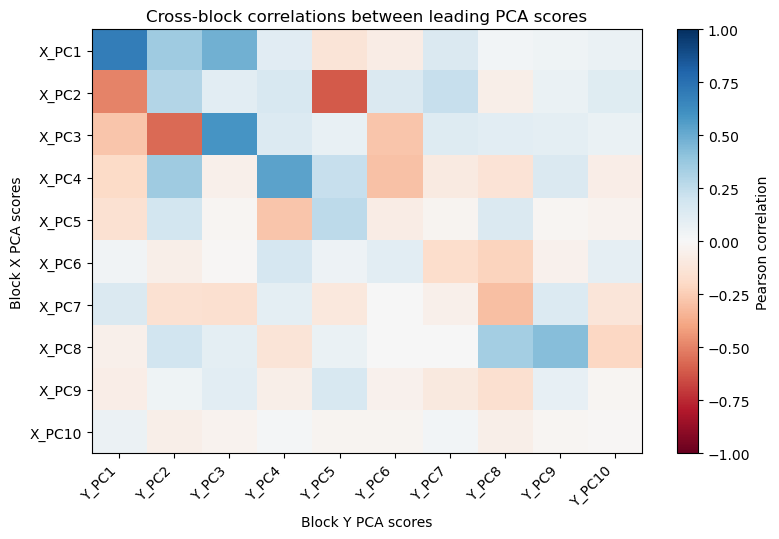

In [36]:
plt.figure(figsize=(8, 5.5))
plt.imshow(pc_corr.values, aspect="auto", vmin=-1, vmax=1, cmap = 'RdBu')
plt.colorbar(label="Pearson correlation")
plt.xticks(np.arange(len(y_pc_cols)), y_pc_cols, rotation=45, ha="right")
plt.yticks(np.arange(len(x_pc_cols)), x_pc_cols)
plt.xlabel("Block Y PCA scores")
plt.ylabel("Block X PCA scores")
plt.title("Cross-block correlations between leading PCA scores")
plt.tight_layout()
plt.savefig(BLOCK_FIGURES_DIR / "cross_block_pc_score_correlation_heatmap.png", dpi=200)
plt.show()

# 6. CCA-Based Joint Latent Scores

In [37]:
n_cca_components = int(min(MAX_CCA_COMPONENTS, n_x_pcs_assoc, n_y_pcs_assoc))
cca = CCA(n_components=n_cca_components, scale=True, max_iter=1000, tol=1e-6)
X_c, Y_c = cca.fit_transform(X_pc_scores, Y_pc_scores)

canonical_correlations = []
for i in range(n_cca_components):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    if corr < 0:
        Y_c[:, i] = -Y_c[:, i]
        corr = -corr
    canonical_correlations.append(corr)

canonical_correlations_df = pd.DataFrame({
    "joint_component": np.arange(1, n_cca_components + 1),
    "canonical_correlation": canonical_correlations,
})
canonical_correlations_df.to_csv(
    RESULTS_DIR / "o2pls_inspired_cca_canonical_correlations.csv",
    index=False,
)

joint_scores_df = pd.DataFrame({
    "SMILES": desc_train[smiles_col].astype(str).values,
    "pIC50": y.values,
})

for i in range(n_cca_components):
    joint_scores_df[f"X_joint{i+1}"] = X_c[:, i]
    joint_scores_df[f"Y_joint{i+1}"] = Y_c[:, i]
    joint_scores_df[f"joint_avg{i+1}"] = 0.5 * (X_c[:, i] + Y_c[:, i])

for col in admet_train.columns:
    if col != smiles_col:
        joint_scores_df[col] = admet_train[col].values

joint_scores_df.to_csv(RESULTS_DIR / "o2pls_inspired_cca_joint_scores.csv", index=False)

display(canonical_correlations_df)
display(joint_scores_df.head())

,joint_component,canonical_correlation
0,1,0.984082
1,2,0.943819
2,3,0.931687
3,4,0.813782
4,5,0.794563


,SMILES,pIC50,X_joint1,Y_joint1,joint_avg1,X_joint2,Y_joint2,joint_avg2,X_joint3,Y_joint3,...,Y_joint4,joint_avg4,X_joint5,Y_joint5,joint_avg5,Caco-2,CYP3A4,hERG,HOB,MN
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,8.602060,0.672621,0.753923,0.713272,0.938211,0.849445,0.893828,-0.969858,-0.976647,...,1.212859,0.851047,0.868325,1.228924,1.048625,0,1,1,0,0
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,8.124939,0.846436,1.079511,0.962973,1.045619,1.151979,1.098799,-1.038580,-1.079077,...,1.341021,0.894942,0.833357,1.563400,1.198379,0,1,1,0,0
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,8.508638,1.037669,0.942093,0.989881,-0.027638,-0.073418,-0.050528,-0.900642,-0.798452,...,0.464819,0.425169,0.894091,1.108957,1.001524,0,1,1,0,1
3,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,8.408935,0.803964,1.067105,0.935535,1.046872,0.906724,0.976798,-1.026405,-1.199634,...,1.114857,0.786312,0.853866,1.440343,1.147104,0,1,1,0,0
4,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,8.130768,0.975174,0.960364,0.967769,0.212096,0.106056,0.159076,-1.052765,-1.111333,...,0.811050,0.770799,0.703260,1.020171,0.861716,0,1,1,0,0


In [38]:
# Sensitivity check for CCA-based joint scores after excluding extreme block-PC score profiles
# checks whether the first canonical association is dominated by a small number of extreme compounds

combined_pc_scores = np.column_stack([X_pc_scores, Y_pc_scores])
combined_pc_scores_scaled = StandardScaler().fit_transform(combined_pc_scores)

pc_score_distance = np.sqrt(np.sum(combined_pc_scores_scaled ** 2, axis=1))
central_mask = pc_score_distance <= np.quantile(pc_score_distance, 0.99)

X_pc_scores_central = X_pc_scores[central_mask]
Y_pc_scores_central = Y_pc_scores[central_mask]

n_cca_components_central = int(
    min(MAX_CCA_COMPONENTS, X_pc_scores_central.shape[1], Y_pc_scores_central.shape[1])
)

cca_central = CCA(
    n_components=n_cca_components_central,
    scale=True,
    max_iter=1000,
    tol=1e-6,
)

X_c_central, Y_c_central = cca_central.fit_transform(
    X_pc_scores_central,
    Y_pc_scores_central,
)

canonical_correlations_central = []
for i in range(n_cca_components_central):
    corr = np.corrcoef(X_c_central[:, i], Y_c_central[:, i])[0, 1]
    canonical_correlations_central.append(abs(corr))

cca_sensitivity_df = pd.DataFrame({
    "joint_component": np.arange(1, n_cca_components_central + 1),
    "canonical_correlation_main": canonical_correlations[:n_cca_components_central],
    "canonical_correlation_central_99pct": canonical_correlations_central,
    "n_compounds_main": len(X_pc_scores),
    "n_compounds_central_99pct": int(central_mask.sum()),
})

cca_sensitivity_df.to_csv(
    RESULTS_DIR / "o2pls_inspired_cca_canonical_correlation_sensitivity.csv",
    index=False,
)

display(cca_sensitivity_df)

,joint_component,canonical_correlation_main,canonical_correlation_central_99pct,n_compounds_main,n_compounds_central_99pct
0,1,0.984082,0.983943,1974,1954
1,2,0.943819,0.944426,1974,1954
2,3,0.931687,0.883961,1974,1954
3,4,0.813782,0.805018,1974,1954
4,5,0.794563,0.800009,1974,1954


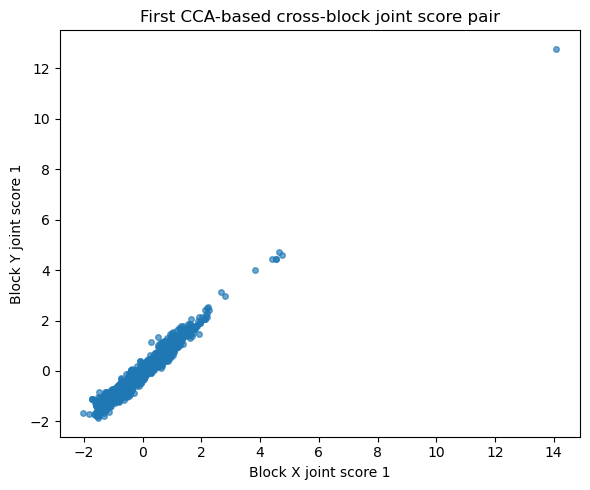

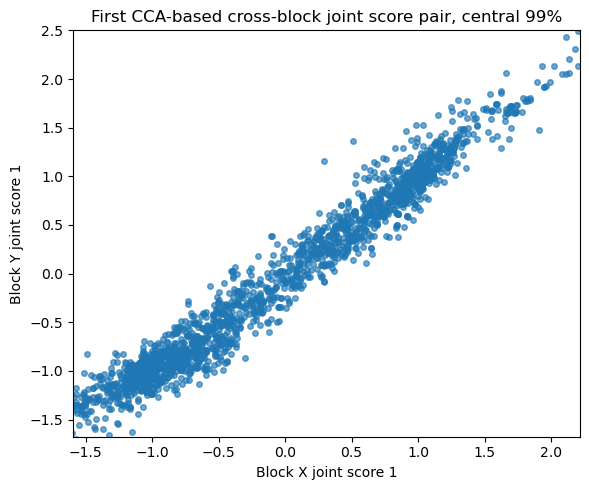

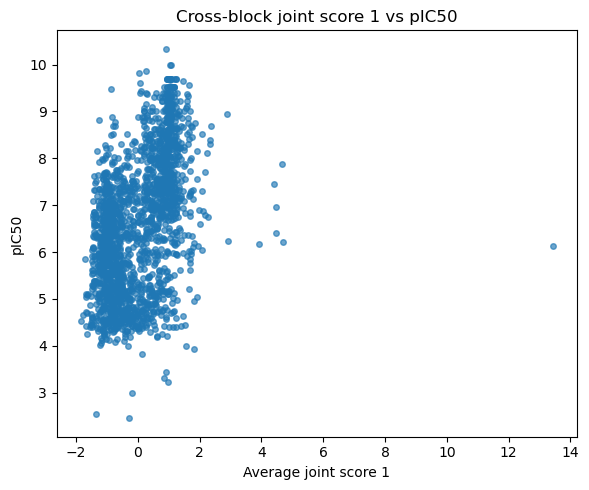

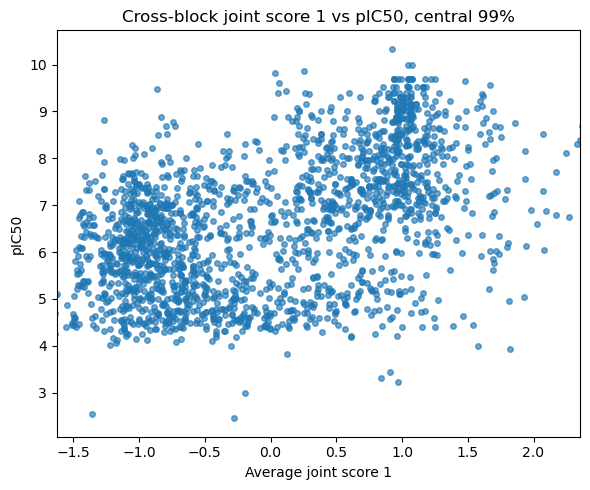

In [39]:
plt.figure(figsize=(6, 5))
plt.scatter(joint_scores_df["X_joint1"], joint_scores_df["Y_joint1"], s=16, alpha=0.65)
plt.xlabel("Block X joint score 1")
plt.ylabel("Block Y joint score 1")
plt.title("First CCA-based cross-block joint score pair")
plt.tight_layout()
plt.savefig(BLOCK_FIGURES_DIR / "cca_joint_score_pair_1.png", dpi=200)
plt.show()

# Zoomed CCA joint score plot for central sample cloud
x_low, x_high = joint_scores_df["X_joint1"].quantile([0.005, 0.995])
y_low, y_high = joint_scores_df["Y_joint1"].quantile([0.005, 0.995])

plt.figure(figsize=(6, 5))
plt.scatter(
    joint_scores_df["X_joint1"],
    joint_scores_df["Y_joint1"],
    s=16,
    alpha=0.65,
)
plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)
plt.xlabel("Block X joint score 1")
plt.ylabel("Block Y joint score 1")
plt.title("First CCA-based cross-block joint score pair, central 99%")
plt.tight_layout()
plt.savefig(
    BLOCK_FIGURES_DIR / "cca_joint_score_pair_1_zoomed.png",
    dpi=200,
)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(joint_scores_df["joint_avg1"], joint_scores_df["pIC50"], s=16, alpha=0.65)
plt.xlabel("Average joint score 1")
plt.ylabel("pIC50")
plt.title("Cross-block joint score 1 vs pIC50")
plt.tight_layout()
plt.savefig(BLOCK_FIGURES_DIR / "joint_score_1_vs_pIC50.png", dpi=200)
plt.show()

# Zoomed joint score vs pIC50 plot
x_low, x_high = joint_scores_df["joint_avg1"].quantile([0.005, 0.995])

plt.figure(figsize=(6, 5))
plt.scatter(
    joint_scores_df["joint_avg1"],
    joint_scores_df["pIC50"],
    s=16,
    alpha=0.65,
)
plt.xlim(x_low, x_high)
plt.xlabel("Average joint score 1")
plt.ylabel("pIC50")
plt.title("Cross-block joint score 1 vs pIC50, central 99%")
plt.tight_layout()
plt.savefig(
    BLOCK_FIGURES_DIR / "joint_score_1_vs_pIC50_zoomed.png",
    dpi=200,
)
plt.show()

# 7. O2PLS-Inspired Joint vs Block-Specific Variation

In [40]:
def cross_block_residual_diagnostics(A_scores, B_scores, prefix):
    model = LinearRegression()
    model.fit(B_scores, A_scores)
    A_hat = model.predict(B_scores)
    residual = A_scores - A_hat

    sst = np.sum((A_scores - A_scores.mean(axis=0, keepdims=True)) ** 2)
    sse = np.sum(residual ** 2)
    r2_matrix = 1 - sse / sst if sst > 0 else np.nan

    component_records = []
    for j in range(A_scores.shape[1]):
        sst_j = np.sum((A_scores[:, j] - A_scores[:, j].mean()) ** 2)
        sse_j = np.sum(residual[:, j] ** 2)
        component_records.append({
            "target_block": prefix,
            "target_pc": j + 1,
            "cross_block_R2": 1 - sse_j / sst_j if sst_j > 0 else np.nan,
            "specific_residual_fraction": sse_j / sst_j if sst_j > 0 else np.nan,
        })

    return A_hat, residual, r2_matrix, pd.DataFrame(component_records)

X_hat_from_Y, X_specific_pc_residual, X_from_Y_r2, X_specific_by_pc = cross_block_residual_diagnostics(
    X_pc_scores,
    Y_pc_scores,
    "Block_X_predicted_from_Block_Y",
)

Y_hat_from_X, Y_specific_pc_residual, Y_from_X_r2, Y_specific_by_pc = cross_block_residual_diagnostics(
    Y_pc_scores,
    X_pc_scores,
    "Block_Y_predicted_from_Block_X",
)

cross_block_variance_summary = pd.DataFrame([
    {
        "target_block": "Block_X",
        "predictor_block": "Block_Y",
        "n_target_pcs": n_x_pcs_assoc,
        "n_predictor_pcs": n_y_pcs_assoc,
        "cross_block_R2_retained_PC_space": X_from_Y_r2,
        "specific_residual_fraction_retained_PC_space": 1 - X_from_Y_r2,
    },
    {
        "target_block": "Block_Y",
        "predictor_block": "Block_X",
        "n_target_pcs": n_y_pcs_assoc,
        "n_predictor_pcs": n_x_pcs_assoc,
        "cross_block_R2_retained_PC_space": Y_from_X_r2,
        "specific_residual_fraction_retained_PC_space": 1 - Y_from_X_r2,
    },
])

cross_block_variance_by_pc = pd.concat([X_specific_by_pc, Y_specific_by_pc], ignore_index=True)

cross_block_variance_summary.to_csv(
    RESULTS_DIR / "o2pls_inspired_cross_block_variance_summary.csv",
    index=False,
)
cross_block_variance_by_pc.to_csv(
    RESULTS_DIR / "o2pls_inspired_cross_block_variance_by_pc.csv",
    index=False,
)

display(cross_block_variance_summary)
display(cross_block_variance_by_pc.head(20))

,target_block,predictor_block,n_target_pcs,n_predictor_pcs,cross_block_R2_retained_PC_space,specific_residual_fraction_retained_PC_space
0,Block_X,Block_Y,10,10,0.618801,0.381199
1,Block_Y,Block_X,10,10,0.655883,0.344117


,target_block,target_pc,cross_block_R2,specific_residual_fraction
0,Block_X_predicted_from_Block_Y,1,0.891865,0.108135
1,Block_X_predicted_from_Block_Y,2,0.846383,0.153617
2,Block_X_predicted_from_Block_Y,3,0.889407,0.110593
3,Block_X_predicted_from_Block_Y,4,0.645470,0.354530
4,Block_X_predicted_from_Block_Y,5,0.232612,0.767388
5,Block_X_predicted_from_Block_Y,6,0.137726,0.862274
6,Block_X_predicted_from_Block_Y,7,0.219188,0.780812
7,Block_X_predicted_from_Block_Y,8,0.408506,0.591494
8,Block_X_predicted_from_Block_Y,9,0.090654,0.909346
9,Block_X_predicted_from_Block_Y,10,0.013705,0.986295


In [41]:
def residual_pca_scores(residual_matrix, label, n_components=3):
    n_components = int(min(n_components, residual_matrix.shape[0] - 1, residual_matrix.shape[1]))
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    scores = pca.fit_transform(residual_matrix)
    score_cols = [f"{label}_specific{i+1}" for i in range(n_components)]
    scores_df = pd.DataFrame(scores, columns=score_cols)
    return pca, scores_df

x_specific_pca, x_specific_scores_df = residual_pca_scores(X_specific_pc_residual, "Block_X")
y_specific_pca, y_specific_scores_df = residual_pca_scores(Y_specific_pc_residual, "Block_Y")

specific_scores_df = pd.DataFrame({
    "SMILES": desc_train[smiles_col].astype(str).values,
    "pIC50": y.values,
})
specific_scores_df = pd.concat([specific_scores_df, x_specific_scores_df, y_specific_scores_df], axis=1)

for col in admet_train.columns:
    if col != smiles_col:
        specific_scores_df[col] = admet_train[col].values

specific_scores_df.to_csv(RESULTS_DIR / "o2pls_inspired_block_specific_scores.csv", index=False)

display(specific_scores_df.head())

,SMILES,pIC50,Block_X_specific1,Block_X_specific2,Block_X_specific3,Block_Y_specific1,Block_Y_specific2,Block_Y_specific3,Caco-2,CYP3A4,hERG,HOB,MN
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,8.602060,-0.346148,-2.176387,2.112092,0.697254,1.884089,-0.428112,0,1,1,0,0
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,8.124939,-1.628192,-1.252323,1.962467,-0.915333,-1.728213,0.846138,0,1,1,0,0
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,8.508638,1.476043,-2.424305,0.072833,-0.297794,0.474427,-0.584518,0,1,1,0,1
3,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,8.408935,-1.172851,-2.468744,1.618450,-0.953342,0.526789,-0.152018,0,1,1,0,0
4,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,8.130768,-0.749987,-1.614259,-0.188384,-1.138289,0.229587,-0.438482,0,1,1,0,0


# 8. Association of Block-Level Scores With pIC50 and ADMET


In [42]:
# Build one combined score table for association summaries
association_scores_df = pd.DataFrame({
    "SMILES": desc_train[smiles_col].astype(str).values,
    "pIC50": y.values,
})

# Include leading within-block PC scores
for i in range(min(5, block_x_pca["scores"].shape[1])):
    association_scores_df[f"Block_X_PC{i+1}"] = block_x_pca["scores"][:, i]
for i in range(min(5, block_y_pca["scores"].shape[1])):
    association_scores_df[f"Block_Y_PC{i+1}"] = block_y_pca["scores"][:, i]

# Include CCA-based joint scores
for i in range(n_cca_components):
    association_scores_df[f"joint_avg{i+1}"] = joint_scores_df[f"joint_avg{i+1}"].values

# Include leading block-specific residual scores
for col in x_specific_scores_df.columns:
    association_scores_df[col] = x_specific_scores_df[col].values
for col in y_specific_scores_df.columns:
    association_scores_df[col] = y_specific_scores_df[col].values

for col in admet_train.columns:
    if col != smiles_col:
        association_scores_df[col] = admet_train[col].values

score_cols_for_assoc = [
    c for c in association_scores_df.columns
    if c not in ["SMILES", "pIC50"] and c not in admet_train.columns
]

activity_corr_records = []
for score_col in score_cols_for_assoc:
    pearson_corr = association_scores_df[[score_col, "pIC50"]].corr(method="pearson").iloc[0, 1]
    spearman_corr = association_scores_df[[score_col, "pIC50"]].corr(method="spearman").iloc[0, 1]
    activity_corr_records.append({
        "score": score_col,
        "pearson_corr_with_pIC50": pearson_corr,
        "abs_pearson_corr_with_pIC50": abs(pearson_corr),
        "spearman_corr_with_pIC50": spearman_corr,
        "abs_spearman_corr_with_pIC50": abs(spearman_corr),
    })

activity_score_correlations = pd.DataFrame(activity_corr_records).sort_values(
    "abs_pearson_corr_with_pIC50",
    ascending=False,
)
activity_score_correlations.to_csv(
    RESULTS_DIR / "o2pls_latent_score_activity_correlations.csv",
    index=False,
)

display(activity_score_correlations.head(20))

,score,pearson_corr_with_pIC50,abs_pearson_corr_with_pIC50,spearman_corr_with_pIC50,abs_spearman_corr_with_pIC50
2,Block_X_PC3,-0.454174,0.454174,-0.510334,0.510334
10,joint_avg1,0.445634,0.445634,0.470277,0.470277
12,joint_avg3,-0.397611,0.397611,-0.536920,0.536920
5,Block_Y_PC1,0.347025,0.347025,0.394088,0.394088
1,Block_X_PC2,-0.278680,0.278680,-0.299447,0.299447
4,Block_X_PC5,0.277655,0.277655,0.295584,0.295584
7,Block_Y_PC3,-0.267581,0.267581,-0.392769,0.392769
3,Block_X_PC4,-0.246676,0.246676,-0.284902,0.284902
8,Block_Y_PC4,-0.242855,0.242855,-0.229193,0.229193
15,Block_X_specific1,0.223533,0.223533,0.267225,0.267225


In [43]:
admet_cols = [c for c in admet_train.columns if c != smiles_col]
admet_prevalence = (
    association_scores_df[admet_cols]
    .agg(["count", "sum", "mean"])
    .T
    .reset_index()
    .rename(columns={
        "index": "ADMET_endpoint",
        "count": "n_compounds",
        "sum": "n_endpoint_1",
        "mean": "prop_endpoint_1",
    })
)

admet_prevalence["n_endpoint_0"] = (
    admet_prevalence["n_compounds"] - admet_prevalence["n_endpoint_1"]
)

admet_prevalence.to_csv(
    RESULTS_DIR / "o2pls_admet_endpoint_prevalence.csv",
    index=False,
)

display(admet_prevalence)

,ADMET_endpoint,n_compounds,n_endpoint_1,prop_endpoint_1,n_endpoint_0
0,Caco-2,1974.0,759.0,0.384498,1215.0
1,CYP3A4,1974.0,1461.0,0.740122,513.0
2,hERG,1974.0,1099.0,0.556738,875.0
3,HOB,1974.0,509.0,0.257852,1465.0
4,MN,1974.0,1514.0,0.766971,460.0


In [44]:
admet_corr_records = []
for endpoint in admet_cols:
    endpoint_values = association_scores_df[endpoint]
    for score_col in score_cols_for_assoc:
        corr = association_scores_df[[score_col, endpoint]].corr(method="pearson").iloc[0, 1]
        admet_corr_records.append({
            "ADMET_endpoint": endpoint,
            "score": score_col,
            "point_biserial_corr": corr,
            "abs_point_biserial_corr": abs(corr),
        })

admet_score_correlations = pd.DataFrame(admet_corr_records).sort_values(
    "abs_point_biserial_corr",
    ascending=False,
)
admet_score_correlations.to_csv(
    RESULTS_DIR / "o2pls_latent_score_admet_correlations.csv",
    index=False,
)

display(admet_score_correlations.head(30))

,ADMET_endpoint,score,point_biserial_corr,abs_point_biserial_corr
26,CYP3A4,Block_Y_PC1,0.613686,0.613686
10,Caco-2,joint_avg1,-0.565902,0.565902
52,hERG,joint_avg1,0.558078,0.558078
31,CYP3A4,joint_avg1,0.557748,0.557748
2,Caco-2,Block_X_PC3,0.502789,0.502789
47,hERG,Block_Y_PC1,0.467328,0.467328
5,Caco-2,Block_Y_PC1,-0.454266,0.454266
43,hERG,Block_X_PC2,-0.451395,0.451395
95,MN,joint_avg2,-0.435591,0.435591
22,CYP3A4,Block_X_PC2,-0.414961,0.414961


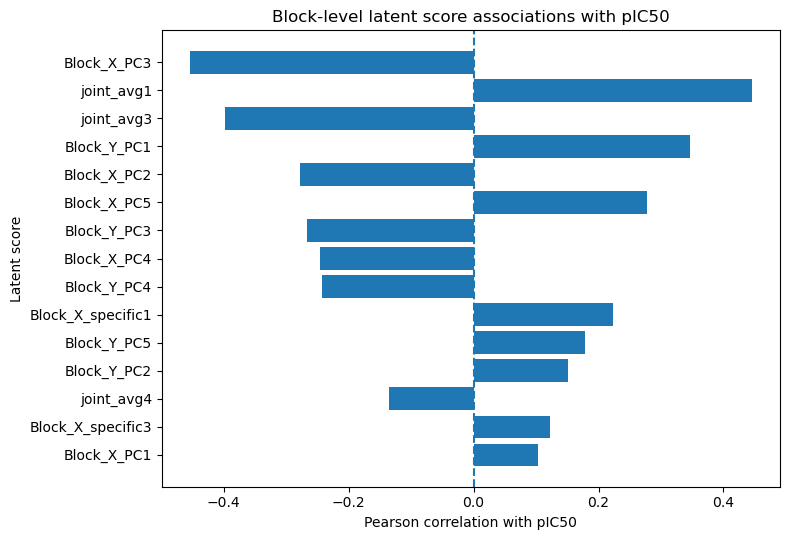

In [45]:
plot_corr_df = activity_score_correlations.head(15).sort_values(
    "abs_pearson_corr_with_pIC50",
    ascending=True,
)

plt.figure(figsize=(8, 5.5))
plt.barh(plot_corr_df["score"], plot_corr_df["pearson_corr_with_pIC50"])
plt.axvline(0, linestyle="--")
plt.xlabel("Pearson correlation with pIC50")
plt.ylabel("Latent score")
plt.title("Block-level latent score associations with pIC50")
plt.tight_layout()
plt.savefig(BLOCK_FIGURES_DIR / "latent_score_correlations_with_pIC50.png", dpi=200)
plt.show()

# 9. Block-Wise PLS Predictive Comparison

The block analysis should not assume that the two candidate blocks contain all supervised pIC50 signal. This section explicitly compares:

1. Block X only;
2. Block Y only;
3. Block X + Block Y;
4. full primary descriptor set with constant descriptors removed;
5. `not_assigned` only as a reference group, not as a candidate O2PLS block.

The `not_assigned` reference is included to quantify how much supervised signal may remain outside the two manually defined candidate blocks.


In [46]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def q2_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    press = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - press / tss)

def make_pls_pipeline(n_components):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components, scale=False, max_iter=500, tol=1e-6)),
    ])

def evaluate_pls_cv(X_df, y, dataset_name, max_components=MAX_PLS_COMPONENTS, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    X_df = X_df.copy().reset_index(drop=True)
    if X_df.isna().sum().sum() > 0:
        X_df = X_df.fillna(X_df.median())
    y = pd.Series(y).astype(float).reset_index(drop=True)
    max_components = int(min(max_components, X_df.shape[1], X_df.shape[0] - 1))

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    summary_records = []
    fold_records = []
    prediction_records = []

    for n_components in range(1, max_components + 1):
        out_of_fold_pred = np.empty(len(y), dtype=float)
        fold_rmses, fold_maes, fold_r2s = [], [], []

        for fold_id, (train_idx, val_idx) in enumerate(cv.split(X_df), start=1):
            model = make_pls_pipeline(n_components)
            model.fit(X_df.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X_df.iloc[val_idx]).ravel()
            out_of_fold_pred[val_idx] = pred

            fold_rmse = rmse(y.iloc[val_idx], pred)
            fold_mae = float(mean_absolute_error(y.iloc[val_idx], pred))
            fold_r2 = float(r2_score(y.iloc[val_idx], pred))
            fold_rmses.append(fold_rmse)
            fold_maes.append(fold_mae)
            fold_r2s.append(fold_r2)

            fold_records.append({
                "dataset_name": dataset_name,
                "n_components": n_components,
                "fold": fold_id,
                "rmse": fold_rmse,
                "mae": fold_mae,
                "r2": fold_r2,
            })

        prediction_records.append(pd.DataFrame({
            "dataset_name": dataset_name,
            "n_components": n_components,
            "SMILES": desc_train[smiles_col].astype(str).values,
            "observed_pIC50": y.values,
            "predicted_pIC50_cv": out_of_fold_pred,
            "residual_cv": y.values - out_of_fold_pred,
            "abs_residual_cv": np.abs(y.values - out_of_fold_pred),
        }))

        summary_records.append({
            "dataset_name": dataset_name,
            "n_components": n_components,
            "n_descriptors": X_df.shape[1],
            "rmse_cv_global": rmse(y, out_of_fold_pred),
            "mae_cv_global": float(mean_absolute_error(y, out_of_fold_pred)),
            "q2_cv_global": q2_score(y, out_of_fold_pred),
            "r2_cv_global": float(r2_score(y, out_of_fold_pred)),
            "fold_rmse_mean": float(np.mean(fold_rmses)),
            "fold_rmse_sd": float(np.std(fold_rmses, ddof=1)),
            "fold_rmse_se": float(np.std(fold_rmses, ddof=1) / np.sqrt(n_splits)),
            "fold_mae_mean": float(np.mean(fold_maes)),
            "fold_r2_mean": float(np.mean(fold_r2s)),
        })

    summary = pd.DataFrame(summary_records)
    fold_metrics = pd.DataFrame(fold_records)
    predictions = pd.concat(prediction_records, ignore_index=True)

    best_row = summary.loc[summary["fold_rmse_mean"].idxmin()].copy()
    one_se_cutoff = best_row["fold_rmse_mean"] + best_row["fold_rmse_se"]
    one_se_row = summary[summary["fold_rmse_mean"] <= one_se_cutoff].sort_values("n_components").iloc[0].copy()

    summary["is_best_rmse"] = summary["n_components"] == int(best_row["n_components"])
    summary["is_one_se_choice"] = summary["n_components"] == int(one_se_row["n_components"])

    return {
        "summary": summary,
        "fold_metrics": fold_metrics,
        "predictions": predictions,
        "best_n_components": int(best_row["n_components"]),
        "one_se_n_components": int(one_se_row["n_components"]),
    }

In [47]:
primary_descriptors = primary_metadata["descriptor"].tolist()
block_xy_descriptors = sorted(set(block_x_descriptors) | set(block_y_descriptors))

pls_block_datasets = {
    "block_X_only": block_x_descriptors,
    "block_Y_only": block_y_descriptors,
    "block_X_plus_block_Y": block_xy_descriptors,
    "primary_full_constant_removed": primary_descriptors,
}

if len(not_assigned_descriptors) > 0:
    pls_block_datasets["not_assigned_reference_only"] = not_assigned_descriptors

block_pls_results = {}
block_pls_summary_tables = []
block_pls_fold_tables = []
block_pls_prediction_tables = []

for dataset_name, descriptors in pls_block_datasets.items():
    print("\n" + "=" * 80)
    print("Evaluating block-wise PLS dataset:", dataset_name)
    print("Number of descriptors:", len(descriptors))

    X_df = X_all[descriptors].copy()
    result = evaluate_pls_cv(
        X_df,
        y,
        dataset_name=dataset_name,
        max_components=min(MAX_PLS_COMPONENTS, len(descriptors)),
    )
    block_pls_results[dataset_name] = result
    block_pls_summary_tables.append(result["summary"])
    block_pls_fold_tables.append(result["fold_metrics"])
    block_pls_prediction_tables.append(result["predictions"])

    print("Best n_components by mean fold RMSE:", result["best_n_components"])
    print("One-SE selected n_components:", result["one_se_n_components"])

block_pls_cv_summary = pd.concat(block_pls_summary_tables, ignore_index=True)
block_pls_cv_fold_metrics = pd.concat(block_pls_fold_tables, ignore_index=True)
block_pls_cv_predictions = pd.concat(block_pls_prediction_tables, ignore_index=True)

block_pls_cv_summary.to_csv(RESULTS_DIR / "o2pls_blockwise_pls_cv_summary.csv", index=False)
block_pls_cv_fold_metrics.to_csv(RESULTS_DIR / "o2pls_blockwise_pls_cv_fold_metrics.csv", index=False)
block_pls_cv_predictions.to_csv(RESULTS_DIR / "o2pls_blockwise_pls_cv_predictions.csv", index=False)

display(block_pls_cv_summary.head())


Evaluating block-wise PLS dataset: block_X_only
Number of descriptors: 335
Best n_components by mean fold RMSE: 29
One-SE selected n_components: 15

Evaluating block-wise PLS dataset: block_Y_only
Number of descriptors: 129
Best n_components by mean fold RMSE: 23
One-SE selected n_components: 19

Evaluating block-wise PLS dataset: block_X_plus_block_Y
Number of descriptors: 464
Best n_components by mean fold RMSE: 26
One-SE selected n_components: 15

Evaluating block-wise PLS dataset: primary_full_constant_removed
Number of descriptors: 504
Best n_components by mean fold RMSE: 27
One-SE selected n_components: 23

Evaluating block-wise PLS dataset: not_assigned_reference_only
Number of descriptors: 40
Best n_components by mean fold RMSE: 5
One-SE selected n_components: 5


,dataset_name,n_components,n_descriptors,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
0,block_X_only,1,335,1.038520,0.828908,0.467125,0.467125,1.037869,0.041543,0.018578,0.828919,0.466248,False,False
1,block_X_only,2,335,0.974225,0.764225,0.531063,0.531063,0.973511,0.041992,0.018779,0.764238,0.530280,False,False
2,block_X_only,3,335,0.958908,0.742061,0.545692,0.545692,0.957701,0.053884,0.024098,0.742074,0.545163,False,False
3,block_X_only,4,335,0.923794,0.718993,0.578356,0.578356,0.923124,0.039794,0.017796,0.719007,0.577314,False,False
4,block_X_only,5,335,0.913700,0.708451,0.587520,0.587520,0.913360,0.028042,0.012541,0.708457,0.586567,False,False


In [48]:
selected_rows = []
for dataset_name, result in block_pls_results.items():
    summary = result["summary"]
    one_se_n = result["one_se_n_components"]
    best_n = result["best_n_components"]

    one_se_row = summary.loc[summary["n_components"] == one_se_n].iloc[0].to_dict()
    best_row = summary.loc[summary["n_components"] == best_n].iloc[0].to_dict()

    one_se_row.update({
        "selection_rule": "one_standard_error",
        "selected_n_components": one_se_n,
    })
    best_row.update({
        "selection_rule": "minimum_mean_fold_RMSE",
        "selected_n_components": best_n,
    })

    selected_rows.extend([one_se_row, best_row])

block_pls_selected_comparison = pd.DataFrame(selected_rows)
block_pls_selected_comparison.to_csv(
    RESULTS_DIR / "o2pls_blockwise_pls_selected_model_comparison.csv",
    index=False,
)

display(
    block_pls_selected_comparison[
        [
            "dataset_name",
            "selection_rule",
            "n_descriptors",
            "selected_n_components",
            "fold_rmse_mean",
            "rmse_cv_global",
            "mae_cv_global",
            "q2_cv_global",
            "r2_cv_global",
        ]
    ].sort_values(["selection_rule", "fold_rmse_mean"])
)

,dataset_name,selection_rule,n_descriptors,selected_n_components,fold_rmse_mean,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global
5,block_X_plus_block_Y,minimum_mean_fold_RMSE,464,26,0.833522,0.834271,0.635453,0.656117,0.656117
7,primary_full_constant_removed,minimum_mean_fold_RMSE,504,27,0.836947,0.837575,0.635864,0.653388,0.653388
1,block_X_only,minimum_mean_fold_RMSE,335,29,0.863398,0.865275,0.665768,0.630083,0.630083
3,block_Y_only,minimum_mean_fold_RMSE,129,23,0.897316,0.897764,0.693128,0.601783,0.601783
9,not_assigned_reference_only,minimum_mean_fold_RMSE,40,5,1.024770,1.025316,0.810248,0.480588,0.480588
6,primary_full_constant_removed,one_standard_error,504,23,0.847433,0.848254,0.638853,0.644493,0.644493
4,block_X_plus_block_Y,one_standard_error,464,15,0.850387,0.851002,0.644076,0.642186,0.642186
0,block_X_only,one_standard_error,335,15,0.890265,0.892142,0.670494,0.606754,0.606754
2,block_Y_only,one_standard_error,129,19,0.909290,0.910157,0.702683,0.590712,0.590712
8,not_assigned_reference_only,one_standard_error,40,5,1.024770,1.025316,0.810248,0.480588,0.480588


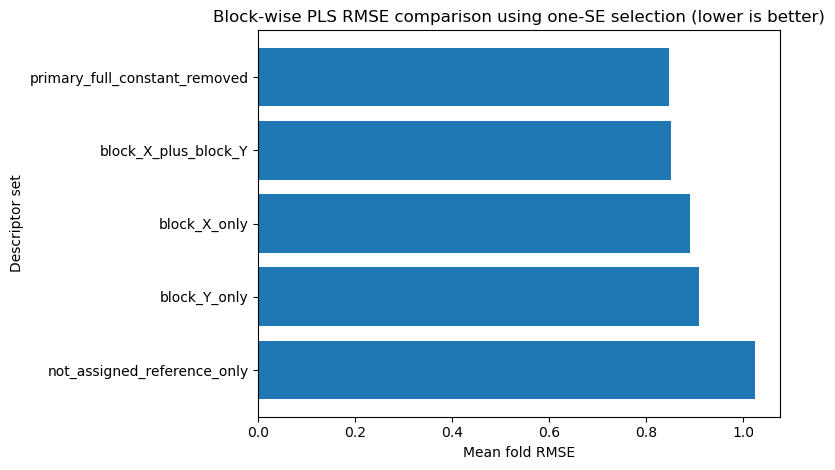

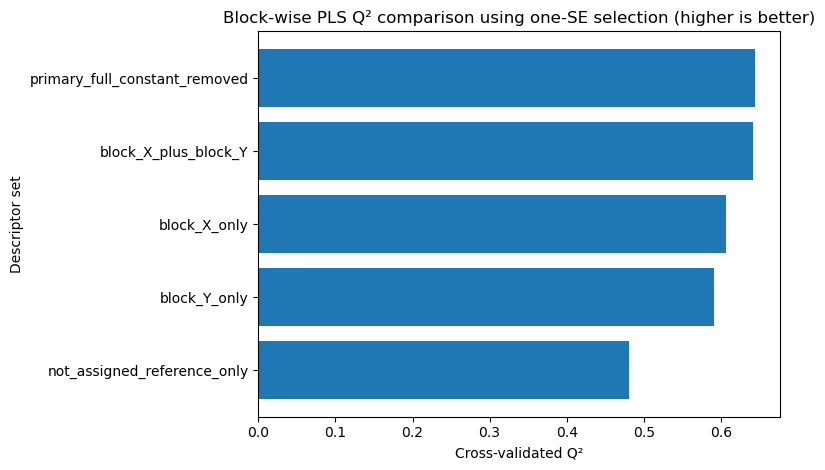

In [49]:
plot_df = block_pls_selected_comparison[
    block_pls_selected_comparison["selection_rule"] == "one_standard_error"
].copy()

# RMSE
rmse_plot_df = plot_df.sort_values("fold_rmse_mean", ascending=False)

plt.figure(figsize=(8, 4.8))
plt.barh(rmse_plot_df["dataset_name"], rmse_plot_df["fold_rmse_mean"])
plt.xlabel("Mean fold RMSE")
plt.ylabel("Descriptor set")
plt.title("Block-wise PLS RMSE comparison using one-SE selection (lower is better)")
plt.tight_layout()
plt.savefig(
    BLOCK_FIGURES_DIR / "blockwise_pls_one_se_rmse_comparison.png",
    dpi=200,
)
plt.show()

# q2
q2_plot_df = plot_df.sort_values("q2_cv_global", ascending=True)

plt.figure(figsize=(8, 4.8))
plt.barh(q2_plot_df["dataset_name"], q2_plot_df["q2_cv_global"])
plt.xlabel("Cross-validated Q²")
plt.ylabel("Descriptor set")
plt.title("Block-wise PLS Q² comparison using one-SE selection (higher is better)")
plt.tight_layout()
plt.savefig(
    BLOCK_FIGURES_DIR / "blockwise_pls_one_se_q2_comparison.png",
    dpi=200,
)
plt.show()

# 10. Summary Tables for Reporting

In [22]:
summary_for_report = {
    "n_block_X_descriptors": len(block_x_descriptors),
    "n_block_Y_descriptors": len(block_y_descriptors),
    "n_block_X_plus_Y_descriptors": len(block_xy_descriptors),
    "n_not_assigned_reference_descriptors": len(not_assigned_descriptors),
    "n_x_pcs_for_cross_block_association": n_x_pcs_assoc,
    "n_y_pcs_for_cross_block_association": n_y_pcs_assoc,
    "n_cca_joint_components": n_cca_components,
    "first_canonical_correlation": canonical_correlations[0] if len(canonical_correlations) > 0 else np.nan,
    "block_X_from_block_Y_R2_retained_PC_space": X_from_Y_r2,
    "block_Y_from_block_X_R2_retained_PC_space": Y_from_X_r2,
}

# Add selected block-wise PLS results.
one_se_comparison = block_pls_selected_comparison[
    block_pls_selected_comparison["selection_rule"] == "one_standard_error"
]
for _, row in one_se_comparison.iterrows():
    prefix = safe_filename(row["dataset_name"])
    summary_for_report[f"{prefix}_one_se_components"] = int(row["selected_n_components"])
    summary_for_report[f"{prefix}_one_se_fold_rmse_mean"] = float(row["fold_rmse_mean"])
    summary_for_report[f"{prefix}_one_se_q2_cv_global"] = float(row["q2_cv_global"])

summary_for_report_df = pd.DataFrame([summary_for_report])
summary_for_report_df.to_csv(
    RESULTS_DIR / "o2pls_inspired_descriptor_block_integration_summary.csv",
    index=False,
)

display(summary_for_report_df.T.rename(columns={0: "value"}))

,value
n_block_X_descriptors,335.000000
n_block_Y_descriptors,129.000000
n_block_X_plus_Y_descriptors,464.000000
n_not_assigned_reference_descriptors,40.000000
n_x_pcs_for_cross_block_association,10.000000
n_y_pcs_for_cross_block_association,10.000000
n_cca_joint_components,5.000000
first_canonical_correlation,0.984082
block_X_from_block_Y_R2_retained_PC_space,0.618801
block_Y_from_block_X_R2_retained_PC_space,0.655883


# 11. Interpretation Notes

This notebook uses the two pre-defined descriptor blocks without post-hoc expansion. The block definitions are therefore treated as chemically motivated inputs rather than as variables selected to maximise PLS performance.

The within-block PCA results show how compact or heterogeneous each descriptor block is. The cross-block PCA-score correlations and CCA-based joint scores provide exploratory evidence for shared latent structure between the local electronic/atom-environment block and the topological/connectivity block.

Because CCA maximises cross-block correlation by construction, canonical correlations are interpreted as diagnostics of shared block structure rather than as formal proof of an O2PLS decomposition. The central-99% sensitivity check is included to assess whether the first canonical association is dominated by extreme score-space observations.

The signs of PCA- and CCA-derived latent scores are arbitrary. Therefore, the magnitude of association with pIC50 is more important than the sign. Positive and negative correlations are interpreted as opposite orientations of the same latent dimension rather than directional causal effects.

The regression-based residual diagnostics are exploratory and in-sample. They are used to describe block-specific variation in the retained PC score space, not to make predictive claims.

The block-wise PLS comparison is the main supervised check in this notebook. If `block_X_plus_block_Y` performs close to the full primary descriptor set, this suggests that the two chemically defined blocks recover much of the pIC50-relevant descriptor signal. If the full primary set performs better, the appropriate interpretation is that additional supervised signal remains outside the two candidate blocks, not that the block definition should be post-hoc expanded.